# WienerNet — Results Analysis

Thin orchestration notebook for analysing one or more trained runs. All
heavy lifting (metrics computation, temporal aggregation, plotting helpers)
lives in the `wienernet.evaluation` package.

Typical workflow:
1. Train models from the terminal (`python scripts/train.py …`).
2. Run `python scripts/evaluate.py --run outputs/X/ outputs/Y/ …` to produce
   `evaluation_summary/{long,summary}.csv`.
3. Open this notebook to slice + plot whatever you need.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wienernet.evaluation import standard_errors, cross_seed_pivot

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_rows", 200)


## 1. Load the cross-run summary

In [3]:
# Edit this path to point at your evaluation_summary directory
SUMMARY_DIR = Path("./outputs/evaluation_summary")

long_df = pd.read_csv(SUMMARY_DIR / "long.csv")
print(f"long_df: {len(long_df)} rows, columns: {list(long_df.columns)}")
long_df.head()


long_df: 180 rows, columns: ['run', 'variant', 'seed', 'run_dir', 'resolution', 'target', 'metric', 'value', 'n']


,run,variant,seed,run_dir,resolution,target,metric,value,n
0,2026-05-31_21-51-31_paper_main_seed42,piae_sde_sampling,42,/Users/saadzia/Work/phd/PIAE/WienerNet/outputs...,raw,nee,mae,0.860227,15957
1,2026-05-31_21-51-31_paper_main_seed42,piae_sde_sampling,42,/Users/saadzia/Work/phd/PIAE/WienerNet/outputs...,raw,nee,rmse,1.560336,15957
2,2026-05-31_21-51-31_paper_main_seed42,piae_sde_sampling,42,/Users/saadzia/Work/phd/PIAE/WienerNet/outputs...,raw,nee,r2,0.714993,15957
3,2026-05-31_21-51-31_paper_main_seed42,piae_sde_sampling,42,/Users/saadzia/Work/phd/PIAE/WienerNet/outputs...,raw,nee,mmd,0.018572,15957
4,2026-05-31_21-51-31_paper_main_seed42,piae_sde_sampling,42,/Users/saadzia/Work/phd/PIAE/WienerNet/outputs...,raw,nee,kl,0.037740,15957


## 2. Median-across-seeds summary

In [4]:
summary = standard_errors(long_df, group_cols=["variant", "resolution", "target", "metric"])
# Slice to the headline numbers (raw resolution, primary targets)
focus = summary.query("resolution == 'raw' and target in ['nee', 'f', 'E0', 'rb']")
focus


,variant,resolution,target,metric,n_runs,median,mad,q05,q95
0,piae_sde_sampling,raw,nee,mae,1,0.860227,0.0,0.860227,0.860227
1,piae_sde_sampling,raw,nee,rmse,1,1.560336,0.0,1.560336,1.560336
2,piae_sde_sampling,raw,nee,r2,1,0.714993,0.0,0.714993,0.714993
3,piae_sde_sampling,raw,nee,mmd,1,0.018572,0.0,0.018572,0.018572
4,piae_sde_sampling,raw,nee,kl,1,0.037740,0.0,0.037740,0.037740
5,piae_sde_sampling,raw,nee,wasserstein,1,0.109559,0.0,0.109559,0.109559
12,piae_sde_sampling,raw,E0,mae,1,0.024623,0.0,0.024623,0.024623
13,piae_sde_sampling,raw,E0,rmse,1,0.101318,0.0,0.101318,0.101318
14,piae_sde_sampling,raw,E0,r2,1,0.999997,0.0,0.999997,0.999997
15,piae_sde_sampling,raw,E0,mmd,1,0.005310,0.0,0.005310,0.005310


## 3. Headline table: variant × metric (median across seeds)

In [5]:
pivot_nee = cross_seed_pivot(long_df, target="nee", resolution="raw",
                              index="variant", columns="metric", aggfunc="median")
pivot_nee.round(4)


metric,kl,mae,mmd,r2,rmse,wasserstein
variant,,,,,,
piae_sde_sampling,0.0377,0.8602,0.0186,0.715,1.5603,0.1096


## 4. Temporal robustness: how do metrics change across resolutions?

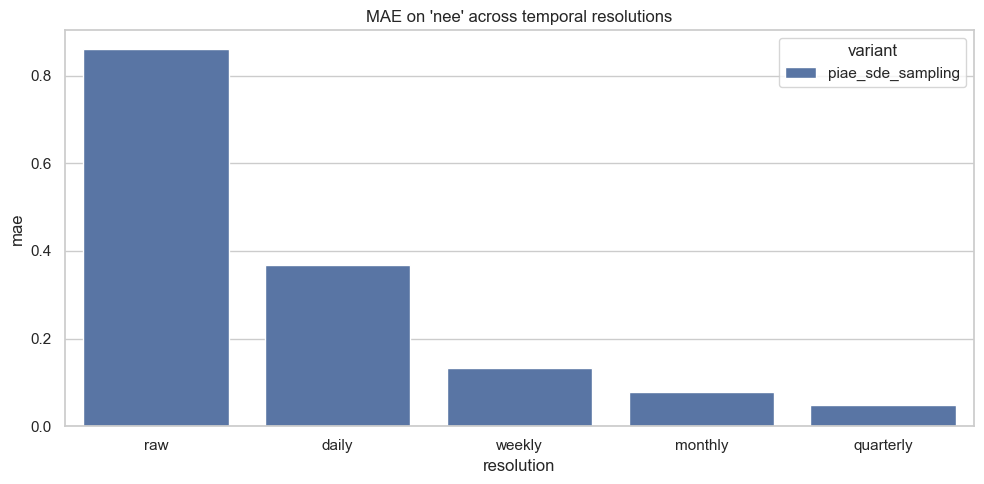

In [6]:
target = "nee"
metric = "mae"
df = long_df[(long_df.target == target) & (long_df.metric == metric)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(df, x="resolution", y="value", hue="variant",
            order=["raw", "daily", "weekly", "monthly", "quarterly"], ax=ax)
ax.set_title(f"{metric.upper()} on '{target}' across temporal resolutions")
ax.set_ylabel(metric)
plt.tight_layout()
plt.show()


## 5. Distributional metrics (MMD, KL, Wasserstein)

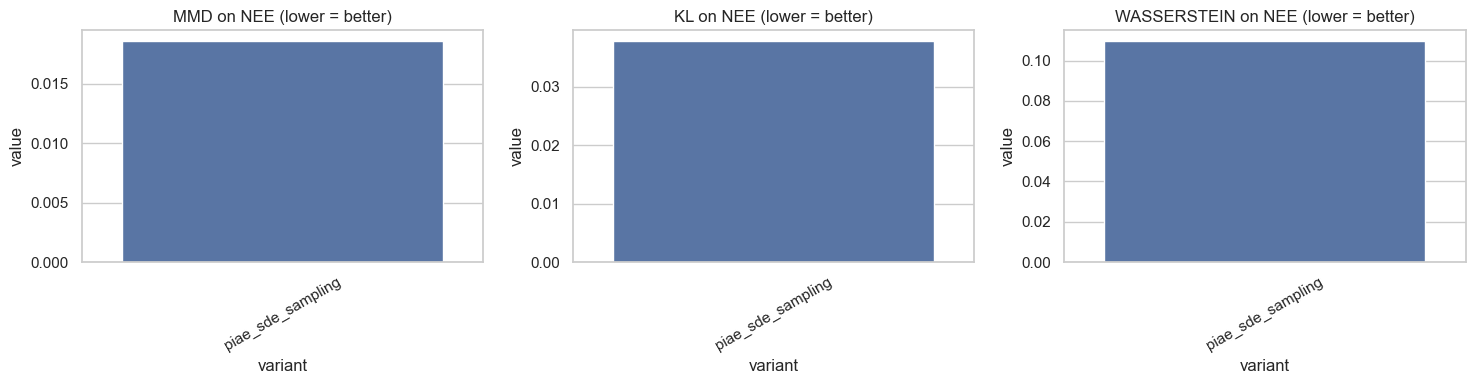

In [7]:
dist_metrics = ["mmd", "kl", "wasserstein"]
dist = long_df[(long_df.target == "nee") &
               (long_df.metric.isin(dist_metrics)) &
               (long_df.resolution == "raw")]

fig, axes = plt.subplots(1, len(dist_metrics), figsize=(15, 4))
for ax, m in zip(axes, dist_metrics):
    sub = dist[dist.metric == m]
    sns.barplot(sub, x="variant", y="value", ax=ax)
    ax.set_title(f"{m.upper()} on NEE (lower = better)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 6. Per-site breakdown (single run)

[PosixPath('outputs/2026-05-31_21-51-31_paper_main_seed42')]
Inspecting: outputs/2026-05-31_21-51-31_paper_main_seed42


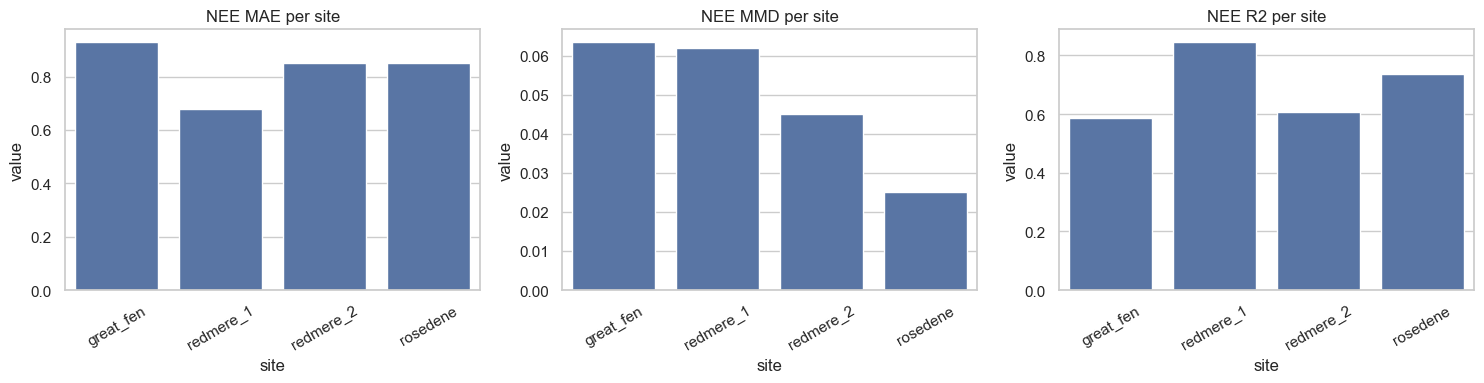

In [24]:
# Pick a run directory to inspect site-level metrics
run_dirs = sorted(Path("./outputs").glob("*paper*"))
print(run_dirs)
RUN_DIR = run_dirs[-1]
print(f"Inspecting: {RUN_DIR}")

per_site = pd.read_csv(RUN_DIR / "metrics" / "per_site.csv")
per_site_focus = per_site.query("target == 'nee' and metric in ['mae', 'mmd', 'r2']")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, ["mae", "mmd", "r2"]):
    sub = per_site_focus[per_site_focus.metric == m]
    sns.barplot(sub, x="site", y="value", ax=ax)
    ax.set_title(f"NEE {m.upper()} per site")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 7. Time-series plot of predictions vs ground truth

In [25]:
# predictions.parquet lives next to each run's metrics/
preds = pd.read_parquet(RUN_DIR / "metrics" / "predictions.parquet")
print(f"predictions: {len(preds)} rows, columns: {list(preds.columns)[:12]}...")
preds.head(3)


predictions: 15957 rows, columns: ['DateTime', 'NEE', 'NEE_sd', 'LE', 'LE_sd', 'H', 'H_sd', 'Tau', 'Tau_sd', 'CO2_strg', 'LE_strg', 'H_strg']...


,DateTime,NEE,NEE_sd,LE,LE_sd,H,H_sd,Tau,Tau_sd,CO2_strg,...,gt_f,pred_nee,pred_bnee,pred_E0,pred_rb,pred_dtemp,pred_f,pred_noise,pred_noise_mus,pred_noise_stds
0,2018-01-01 01:00:00,2.0356,0.1992,10.3438,0.9176,-65.5428,2.8959,-0.2686,-0.1901,0.0106,...,-0.003947,1.946105,1.952802,188.350677,2.303894,-0.054292,-0.006697,-2.776689,-2.776689,1.366300e-09
1,2018-01-01 01:30:00,1.9172,0.2248,5.4877,1.0477,-65.6675,3.0504,-0.5312,-0.2343,0.0117,...,-0.025943,1.843615,1.850210,188.351730,2.304184,-0.053724,-0.006595,-2.842236,-2.842236,1.370102e-09
2,2018-01-01 05:00:00,2.3979,0.2705,5.2166,0.4552,-68.6689,2.8224,0.0223,-0.0427,-0.0270,...,-0.008947,2.108160,2.114132,188.361328,2.313848,-0.049832,-0.005972,-2.685529,-2.685529,1.348812e-09


/var/folders/7r/b0750y3s1vq7yqj7x8mjxc3m0000gn/T/ipykernel_97746/316687320.py:15: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/saadzia/miniconda3/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


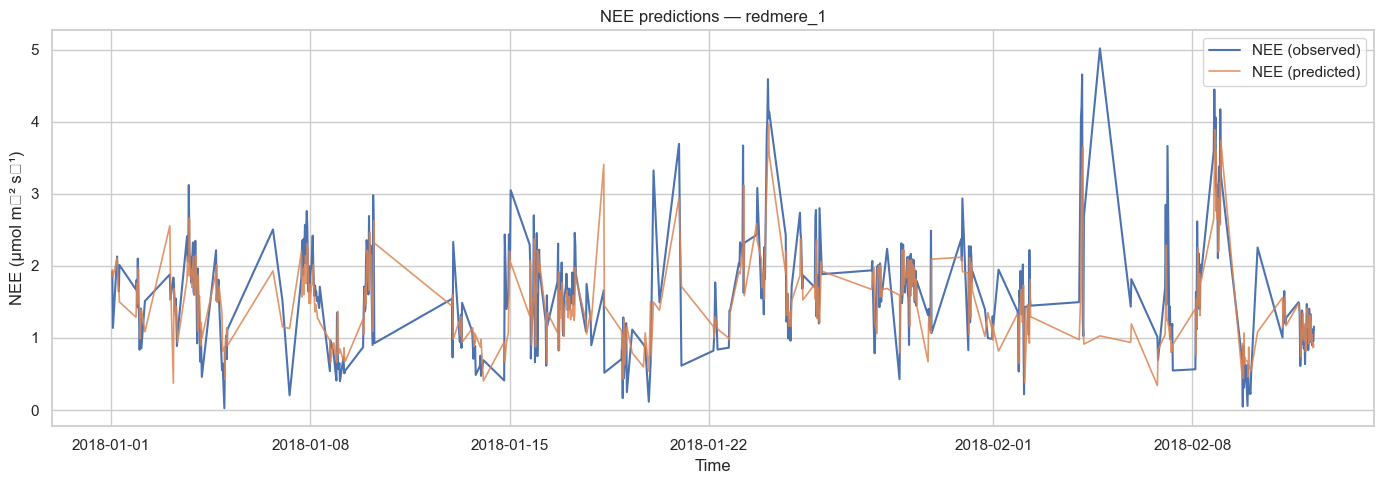

In [26]:
# Plot a slice (one site, one month)
site = preds["site"].iloc[0] if "site" in preds.columns else None
slice_df = preds.copy()
if site is not None:
    slice_df = slice_df[slice_df["site"] == site]
slice_df = slice_df.iloc[:480]   # first ~10 days at 30-min cadence

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(slice_df["DateTime"], slice_df["gt_nee"], label="NEE (observed)", lw=1.5)
ax.plot(slice_df["DateTime"], slice_df["pred_nee"], label="NEE (predicted)", lw=1.2, alpha=0.85)
ax.set_title(f"NEE predictions — {site}")
ax.set_xlabel("Time")
ax.set_ylabel("NEE (µmol m⁻² s⁻¹)")
ax.legend()
plt.tight_layout()
plt.show()
